# Week 4 Lecture Notes: Lindholm Chapter 3 — Basic Parametric Models and Statistical Learning

## Contents

- [Scope for Week 4](#scope-for-week-4)
- [Learning goals for this notebook](#learning-goals-for-this-notebook)
- [Chapter 3 summary](#chapter-3-summary)
  - [Parametric vs non-parametric models](#1-parametric-vs-non-parametric-models)
  - [Linear regression](#2-linear-regression)
    - [The model](#the-model)
    - [Loss functions and cost functions](#loss-functions-and-cost-functions)
    - [Least squares and the normal equations](#least-squares-and-the-normal-equations)
    - [The maximum likelihood perspective](#the-maximum-likelihood-perspective)
    - [Categorical input variables](#categorical-input-variables)
  - [Classification and logistic regression](#3-classification-and-logistic-regression)
    - [Statistical view of classification](#statistical-view-of-classification)
    - [The logistic regression model](#the-logistic-regression-model)
    - [Training by maximum likelihood](#training-by-maximum-likelihood)
    - [Predictions and decision boundaries](#predictions-and-decision-boundaries)
    - [Multiclass logistic regression and softmax](#multiclass-logistic-regression-and-softmax)
  - [Polynomial regression and regularisation](#4-polynomial-regression-and-regularisation)
  - [Generalised linear models](#5-generalised-linear-models)
  - [Key notation summary](#6-key-notation-summary)
- [Past exam-oriented priorities (23-25)](#past-exam-oriented-priorities-23-25)
- [Past exam questions (23-25)](#past-exam-questions-23-25)
- [Toy example 1: linear regression from scratch](#toy-example-1-linear-regression-from-scratch)
- [Toy example 2: logistic regression decision boundary](#toy-example-2-logistic-regression-decision-boundary)
- [Toy example 3: polynomial regression and overfitting](#toy-example-3-polynomial-regression-and-overfitting)
- [Week 4 wrap-up](#week-4-wrap-up)
- [Sources used](#sources-used)

## Scope for Week 4

- Topic: basic parametric models and statistical learning.
- Important concepts: maximum likelihood estimation, discriminant functions, decision rules.
- Models: linear regression, logistic regression, polynomial regression.
- Reading: Lindholm (2022), Chapter 3.
- Prac alignment: Week 4 practical covers basic parametric methods and statistical learning.

## Learning goals for this notebook

1. Understand how parametric models differ from the non-parametric methods in Week 2, and why learning reduces to finding parameter values.
2. Derive and interpret the least-squares solution for linear regression, and connect it to the maximum likelihood perspective under Gaussian noise.
3. Explain how logistic regression adapts the linear model for classification, including the logistic function, cross-entropy loss, and decision boundaries at $g(\mathbf{x}) = 0.5$.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 4702
random.seed(SEED)
np.random.seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 4702


## Chapter 3 summary

### 1. Parametric vs non-parametric models

In Week 2 we studied $k$-NN and decision trees — both **non-parametric** methods that keep the training data around at prediction time. This week introduces **parametric** models: the model is defined by a fixed set of parameters $\boldsymbol{\theta}$ learned from data. Once $\boldsymbol{\theta}$ is learned, the training data can be discarded because predictions depend only on $\boldsymbol{\theta}$.

- **Non-parametric** ($k$-NN, decision trees): prediction uses the training data directly; model complexity can grow with $n$.
- **Parametric** (linear regression, logistic regression): prediction is $\hat{y}(\mathbf{x}_\star) = f(\mathbf{x}_\star; \boldsymbol{\theta})$; model complexity is fixed by the number of parameters.

This distinction matters because parametric models are compact, fast at prediction time, and can be interpreted through their parameter values, but they impose structural assumptions (e.g., linearity) that may not match the data.

---

### 2. Linear regression

#### The model

The linear regression model assumes the output $y$ is an affine function of the inputs plus noise:

$$y = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_p x_p + \varepsilon = \boldsymbol{\theta}^\top \mathbf{x} + \varepsilon \qquad (3.3)$$

where $\boldsymbol{\theta} = [\theta_0 \; \theta_1 \; \ldots \; \theta_p]^\top$ is the parameter vector (with $\theta_0$ as the intercept/offset), $\mathbf{x} = [1 \; x_1 \; \ldots \; x_p]^\top$ is the extended input vector (prepended with 1 for the intercept), and $\varepsilon$ is a zero-mean noise term independent of $\mathbf{x}$.

**Prediction** for a new test input $\mathbf{x}_\star$:

$$\hat{y}(\mathbf{x}_\star) = \hat{\boldsymbol{\theta}}^\top \mathbf{x}_\star \qquad (3.4)$$

The noise $\varepsilon$ is called the **irreducible error** (or aleatoric uncertainty) — it represents randomness in the data that no model can capture.

#### Loss functions and cost functions

A **loss function** $L(\hat{y}, y)$ measures how far one prediction is from the true value. The **cost function** $J(\boldsymbol{\theta})$ averages the loss over the training set:

$$\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \; \frac{1}{n} \sum_{i=1}^{n} L\bigl(\hat{y}(\mathbf{x}_i; \boldsymbol{\theta}),\, y_i\bigr) = \arg\min_{\boldsymbol{\theta}} \; J(\boldsymbol{\theta}) \qquad (3.9)$$

#### Least squares and the normal equations

For regression, the standard choice is the **squared error** loss:

$$L(\hat{y}, y) = (\hat{y} - y)^2 \qquad (3.10)$$

giving the **least squares** cost function:

$$J(\boldsymbol{\theta}) = \frac{1}{n} \|\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\|_2^2 \qquad (3.11)$$

where $\mathbf{X}$ is the $n \times (p+1)$ design matrix (each row is $\mathbf{x}_i^\top$) and $\mathbf{y}$ is the $n$-vector of outputs.

Setting the gradient to zero yields the **normal equations**:

$$\mathbf{X}^\top \mathbf{X} \hat{\boldsymbol{\theta}} = \mathbf{X}^\top \mathbf{y} \qquad (3.13)$$

If $\mathbf{X}^\top \mathbf{X}$ is invertible, this gives the **closed-form** solution:

$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y} \qquad (3.14)$$

This closed-form solution is one of the main advantages of linear regression with squared error loss. Most other loss functions require iterative optimisation (covered in Week 6).

#### The maximum likelihood perspective

Instead of choosing a loss function somewhat arbitrarily, we can derive the same result from a statistical perspective. Assume the noise is Gaussian: $\varepsilon \sim \mathcal{N}(0, \sigma_\varepsilon^2)$. Then maximising the **likelihood** $p(\mathbf{y} \mid \mathbf{X}; \boldsymbol{\theta})$ — i.e., finding the $\boldsymbol{\theta}$ that makes the observed data most probable — is equivalent to minimising the least squares cost:

$$\hat{\boldsymbol{\theta}} = \arg\max_{\boldsymbol{\theta}} \; p(\mathbf{y} \mid \mathbf{X}; \boldsymbol{\theta}) = \arg\min_{\boldsymbol{\theta}} \; \frac{1}{n} \sum_{i=1}^{n} (\boldsymbol{\theta}^\top \mathbf{x}_i - y_i)^2 \qquad (3.21)$$

**Key insight**: using squared error loss is *equivalent* to assuming Gaussian noise and doing maximum likelihood estimation (MLE). Different noise assumptions lead to different loss functions (discussed in Chapter 5).

#### Categorical input variables

Categorical inputs (e.g., colour = {Red, Blue, Green}) are handled by creating **dummy variables** / **one-hot encoding**: one binary variable per category value.

For a two-valued categorical variable, use a single dummy: $x = 0$ if A, $x = 1$ if B $(3.22)$.

For $K$ categories, create $K$ binary indicator variables. This works for any supervised method, not just linear regression.

---

### 3. Classification and logistic regression

#### Statistical view of classification

From a statistical perspective, classification amounts to modelling the conditional class probabilities $p(y = m \mid \mathbf{x})$. For binary classification ($M = 2$, classes $\{-1, +1\}$), we train a model $g(\mathbf{x})$ such that:

$$p(y = 1 \mid \mathbf{x}) \text{ is modelled by } g(\mathbf{x}) \qquad (3.26a)$$

Since probabilities must lie in $[0, 1]$, we need a function that maps from $\mathbb{R}$ to $[0, 1]$.

#### The logistic regression model

The idea: start with the linear model $z = \boldsymbol{\theta}^\top \mathbf{x}$ (the **logit**), then "squeeze" it into $[0, 1]$ using the **logistic function** $h(z) = \frac{e^z}{1 + e^z}$:

$$g(\mathbf{x}) = \frac{e^{\boldsymbol{\theta}^\top \mathbf{x}}}{1 + e^{\boldsymbol{\theta}^\top \mathbf{x}}} \qquad (3.29a)$$

Despite the name, logistic regression is a **classification** method, not a regression method. The name comes from the fact that it applies the logistic function on top of a linear regression model.

**No noise term**: unlike linear regression, there is no additive $\varepsilon$. The randomness in classification is modelled through the probability $p(y \mid \mathbf{x})$ itself.

#### Training by maximum likelihood

Since we cannot use the normal equations (the logistic function makes the problem non-linear), we train by maximising the log-likelihood, which is equivalent to minimising the **cross-entropy** (or **logistic**) loss:

$$J(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^{n} \ln\bigl(1 + e^{-y_i \boldsymbol{\theta}^\top \mathbf{x}_i}\bigr) \qquad (3.35)$$

This has **no closed-form solution** — it requires iterative numerical optimisation (gradient descent, covered in Week 6). But efficient algorithms exist.

#### Predictions and decision boundaries

To make a hard class prediction, pick the most probable class:

$$\hat{y}(\mathbf{x}_\star) = \begin{cases} 1 & \text{if } g(\mathbf{x}) > 0.5 \\ -1 & \text{if } g(\mathbf{x}) \leq 0.5 \end{cases} \qquad (3.36)$$

The **decision boundary** is where $g(\mathbf{x}) = 0.5$, which occurs when $\boldsymbol{\theta}^\top \mathbf{x} = 0$ $(3.38)$. This is always a **(hyper)plane**, making logistic regression a **linear classifier**.

Equivalently: $\hat{y}(\mathbf{x}_\star) = \text{sign}(\boldsymbol{\theta}^\top \mathbf{x}_\star)$ $(3.39)$.

**Exam-critical fact**: at the decision boundary, the output of a standard logistic regression model is $g(\mathbf{x}) = 0.5$.

#### Multiclass logistic regression and softmax

For $M > 2$ classes, logistic regression generalises using the **softmax** function:

$$g_m(\mathbf{x}) = \frac{e^{\boldsymbol{\theta}_m^\top \mathbf{x}}}{\sum_{j=1}^{M} e^{\boldsymbol{\theta}_j^\top \mathbf{x}}}, \quad m = 1, \ldots, M \qquad (3.43)$$

This uses $M$ parameter vectors $\boldsymbol{\theta}_1, \ldots, \boldsymbol{\theta}_M$ (one per class). The softmax guarantees outputs are non-negative and sum to 1. Decision boundaries are $M - 1$ hyperplanes.

---

### 4. Polynomial regression and regularisation

Linear regression assumes a linear relationship between inputs and output. **Polynomial regression** extends this by creating polynomial features:

For a single input $x$, instead of $\hat{y} = \theta_0 + \theta_1 x$, we use:

$$\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_k x^k$$

This is still a **linear model** in the parameters $\boldsymbol{\theta}$ (even though it is non-linear in $x$). We simply create a new input vector $\mathbf{x} = [1 \; x \; x^2 \; \cdots \; x^k]^\top$ and apply the same normal equations.

**Overfitting risk**: high-degree polynomials fit the training data closely but generalise poorly. This is the same flexibility-rigidity trade-off from Week 2.

**Regularisation** (preview of Week 6): to prevent overfitting, add a penalty on the parameter magnitudes:

$$\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \; \frac{1}{n} \|\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\|_2^2 + \lambda \|\boldsymbol{\theta}\|_2^2$$

where $\lambda \geq 0$ is a regularisation hyperparameter. Larger $\lambda$ shrinks parameters toward zero, producing a simpler model. This is called **ridge regression** (L2 regularisation). The regularised normal equations are:

$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^\top \mathbf{X} + n\lambda \mathbf{I})^{-1} \mathbf{X}^\top \mathbf{y}$$

Note: the matrix $\mathbf{X}^\top \mathbf{X} + n\lambda \mathbf{I}$ is always invertible for $\lambda > 0$, even when $\mathbf{X}^\top \mathbf{X}$ is not.

---

### 5. Generalised linear models

Linear regression and logistic regression are both examples of **generalised linear models (GLMs)**. The idea: take a linear combination $z = \boldsymbol{\theta}^\top \mathbf{x}$ and transform it through a **link function** $h(z)$:

| Model | Task | Link function $h(z)$ | Output |
|-------|------|----------------------|--------|
| Linear regression | Regression | Identity: $h(z) = z$ | $\hat{y} = \boldsymbol{\theta}^\top \mathbf{x}$ |
| Logistic regression | Binary classification | Logistic: $h(z) = \frac{e^z}{1+e^z}$ | $g(\mathbf{x}) \in [0,1]$ |
| Softmax regression | Multiclass classification | Softmax | $\mathbf{g}(\mathbf{x}) \in [0,1]^M$, $\sum g_m = 1$ |

This framework unifies the models in this chapter and connects forward to neural networks (Week 7), where non-linear link functions are applied at every hidden layer.

---

### 6. Key notation summary

| Symbol | Meaning |
|--------|---------|
| $\boldsymbol{\theta}$ | Parameter vector $[\theta_0, \theta_1, \ldots, \theta_p]^\top$ |
| $\mathbf{x}$ | Input vector $[1, x_1, \ldots, x_p]^\top$ (with intercept) |
| $\mathbf{X}$ | Design matrix, $n \times (p+1)$ |
| $\mathbf{y}$ | Output vector, $n \times 1$ |
| $\hat{\boldsymbol{\theta}}$ | Learned parameter vector |
| $L(\hat{y}, y)$ | Loss function (per-sample) |
| $J(\boldsymbol{\theta})$ | Cost function (average loss over training set) |
| $g(\mathbf{x})$ | Logistic regression output, models $p(y=1 \mid \mathbf{x})$ |
| $z = \boldsymbol{\theta}^\top \mathbf{x}$ | Logit (linear combination before logistic function) |
| $\varepsilon$ | Noise / irreducible error |
| $\sigma_\varepsilon^2$ | Noise variance |
| $\lambda$ | Regularisation hyperparameter |

---

## Past exam-oriented priorities (23-25)

Concepts from Week 4 that appear repeatedly across the 2023–2025 exams:

1. **Linear vs logistic regression comparison** — differences in task (regression vs classification), training (closed-form vs iterative), loss function (squared error vs cross-entropy), and parameter count (same: $p+1$). Tested in 2024-A-3.
2. **Decision boundary of logistic regression** — at $g(\mathbf{x}) = 0.5$, equivalently $\boldsymbol{\theta}^\top \mathbf{x} = 0$; always a hyperplane (linear classifier). Tested in 2025-A-3.
3. **Linear regression cost function anatomy** — labelling axes, identifying $x_i$, $y_i$, $\hat{y}(x_i; \theta)$, and residuals $\hat{y} - y$ in a figure. Tested in 2025-B-4.
4. **Regularisation hyperparameter $\lambda$** — identifying $\lambda$ in the regularised cost function. Tested in 2024-A-6.
5. **Logistic regression misclassification rate** — drawing the linear decision boundary on a 2D scatter plot. Tested in 2024-B-1.
6. **MLE and least squares equivalence** — under Gaussian noise, MLE gives the same solution as least squares.
7. **Bayesian vs standard linear regression** — connects forward to Week 12 (standard gives a point estimate $\hat{\boldsymbol{\theta}}$; Bayesian gives a distribution over $\boldsymbol{\theta}$). Tested in 2025-B-11.

**Fast revision checklist:**
- Linear regression has a closed-form solution; logistic regression does not.
- Both have $p + 1$ parameters for $p$ inputs.
- Squared error loss $\Leftrightarrow$ Gaussian noise assumption $\Leftrightarrow$ MLE.
- Logistic regression decision boundary: $g(\mathbf{x}) = 0.5 \Leftrightarrow \boldsymbol{\theta}^\top \mathbf{x} = 0$.
- Logistic regression is a linear classifier (hyperplane boundary).
- Polynomial regression is still linear in parameters — overfitting risk increases with degree.
- Regularisation ($\lambda$) trades fit quality for simplicity.

---

## Past exam questions (23-25)

### 2024 Part A, Question 3 (primary week 4)

> Comparing linear regression and logistic regression, which of the following statements is incorrect?
>
> (a) For logistic regression, training can be formulated as maximizing a likelihood function, whereas this is not possible for linear regression.
>
> (b) Training a linear regression model can be formulated such that a closed-form solution is available, while logistic regression requires an iterative training algorithm.
>
> (c) Linear regression is appropriate for solving regression problems, whereas logistic regression is appropriate for solving classification problems.
>
> (d) Given $p$ input variables and a single target variable, the standard linear and logistic regression models have the same number of parameters.

**Answer**: **(a)** is incorrect. Both linear and logistic regression can be trained via MLE. For linear regression, MLE under Gaussian noise is equivalent to least squares (Eq. 3.21). Statement (a) falsely claims MLE is not possible for linear regression.

---

### 2025 Part A, Question 3 (primary week 4)

> Let $g(x_i; \theta)$ be the output of a standard logistic regression model. At the decision boundary, the output of this model is equal to:
>
> (a) 0.5 &emsp; (b) 0 &emsp; (c) 1 &emsp; (d) -1

**Answer**: **(a) 0.5**. The decision boundary is where $g(\mathbf{x}) = 1 - g(\mathbf{x})$, which gives $g(\mathbf{x}) = 0.5$. Equivalently, $\boldsymbol{\theta}^\top \mathbf{x} = 0$ (Eq. 3.38).

---

### 2025 Part B, Question 4 (primary week 4)

> Figure 3 shows linear regression applied to a 1-D dataset. The cost function is:
> $$\hat{\theta} = \arg\min_\theta \frac{1}{n} \sum_{i=1}^n L(\hat{y}(x_i; \theta), y_i)$$
>
> (a) Label the axes in Figure 3.
>
> (b) Draw arrows to show: (i) $x_i$; (ii) $y_i$; (iii) $\hat{y}(x_i; \theta)$; (iv) $\hat{y}(x_i; \theta) - y_i$.
>
> (c) State the value of $n$ from Figure 3.

**Approach**: (a) Horizontal axis = input $x$, vertical axis = output $y$. (b) $x_i$ is a point on the horizontal axis; $y_i$ is the data point's vertical coordinate; $\hat{y}(x_i; \theta)$ is the point on the fitted line directly above $x_i$; $\hat{y} - y_i$ is the vertical distance (residual) between the line and the data point. (c) Count the data points in the figure.

---

### 2024 Part A, Question 6 (secondary — week 6 primary, week 4 content)

> A linear regression model is trained by solving:
> $$\hat{\theta} = \arg\min_\theta \frac{1}{n} \|X\theta - y\|_2^2 + \lambda\|\theta\|_2^2$$
> The regularisation hyperparameter is denoted by:
>
> (a) $\theta$ &emsp; (b) $n$ &emsp; (c) 2 &emsp; (d) $\lambda$

**Answer**: **(d) $\lambda$**. The term $\lambda\|\theta\|_2^2$ is the L2 regularisation penalty; $\lambda$ controls the strength of regularisation.

---

## Toy example 1: linear regression from scratch

Fit a linear regression model to a small 1D dataset using the normal equations, and verify against `numpy.linalg.lstsq`.

Design matrix X shape: (10, 2)
y shape: (10,)

Learned parameters (normal equations):
  theta_0 (intercept) = -20.3793
  theta_1 (slope)     = 2.6946

Verification (np.linalg.lstsq):
  theta_0 = -20.3793
  theta_1 = 2.6946

Mean Squared Error (training): 52.4372


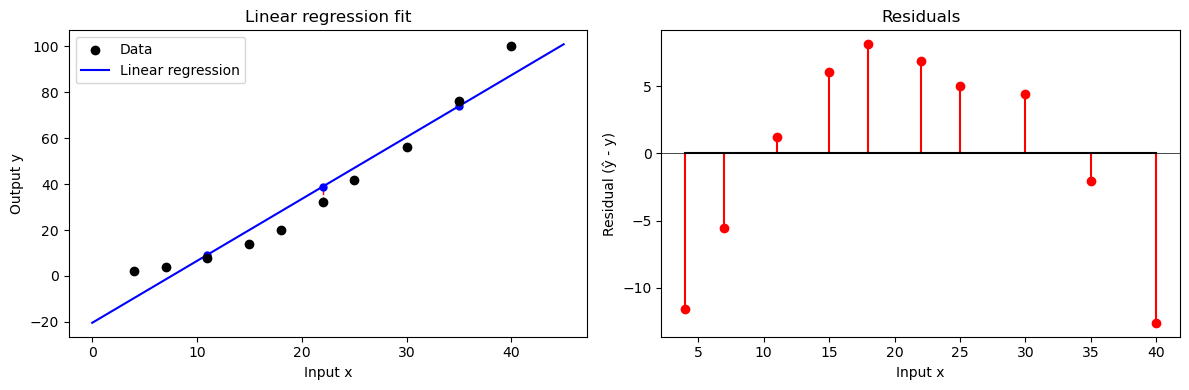

In [2]:
# Toy example 1: linear regression via normal equations

# Small 1D dataset (car-stopping-distance flavour)
x_raw = np.array([4.0, 7.0, 11.0, 15.0, 18.0, 22.0, 25.0, 30.0, 35.0, 40.0])
y = np.array([2.0, 4.0, 8.0, 14.0, 20.0, 32.0, 42.0, 56.0, 76.0, 100.0])
n = len(x_raw)

# Build design matrix X (prepend column of ones for intercept)
X = np.column_stack([np.ones(n), x_raw])
print(f"Design matrix X shape: {X.shape}")  # (10, 2)
print(f"y shape: {y.shape}")                # (10,)

# Normal equations: theta_hat = (X^T X)^{-1} X^T y
XtX = X.T @ X
Xty = X.T @ y
theta_hat = np.linalg.solve(XtX, Xty)
print(f"\nLearned parameters (normal equations):")
print(f"  theta_0 (intercept) = {theta_hat[0]:.4f}")
print(f"  theta_1 (slope)     = {theta_hat[1]:.4f}")

# Verify with numpy lstsq
theta_lstsq, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
print(f"\nVerification (np.linalg.lstsq):")
print(f"  theta_0 = {theta_lstsq[0]:.4f}")
print(f"  theta_1 = {theta_lstsq[1]:.4f}")

# Predictions and residuals
y_hat = X @ theta_hat
residuals = y_hat - y
mse = np.mean(residuals**2)
print(f"\nMean Squared Error (training): {mse:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: data + fitted line
ax = axes[0]
x_line = np.linspace(0, 45, 100)
y_line = theta_hat[0] + theta_hat[1] * x_line
ax.scatter(x_raw, y, color='black', zorder=5, label='Data')
ax.plot(x_line, y_line, color='blue', label='Linear regression')
# Show residuals for a few points
for i in [2, 5, 8]:
    ax.plot([x_raw[i], x_raw[i]], [y[i], y_hat[i]], 'r--', linewidth=1)
    ax.plot(x_raw[i], y_hat[i], 'bo', markersize=5)
ax.set_xlabel('Input x')
ax.set_ylabel('Output y')
ax.set_title('Linear regression fit')
ax.legend()

# Right: residual plot
ax = axes[1]
ax.stem(x_raw, residuals, linefmt='r-', markerfmt='ro', basefmt='k-')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Input x')
ax.set_ylabel('Residual (ŷ - y)')
ax.set_title('Residuals')

plt.tight_layout()
plt.show()

---

## Toy example 2: logistic regression decision boundary

Show how logistic regression produces a linear decision boundary. Train on a small 2D dataset using `sklearn` and plot the boundary at $g(\mathbf{x}) = 0.5$.

/home/user/miniconda3/envs/comp4702/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Learned parameters:
  theta_0 (intercept) = -4.3304
  theta_1 = 0.0080
  theta_2 = 6.5618
Training accuracy: 98.33%


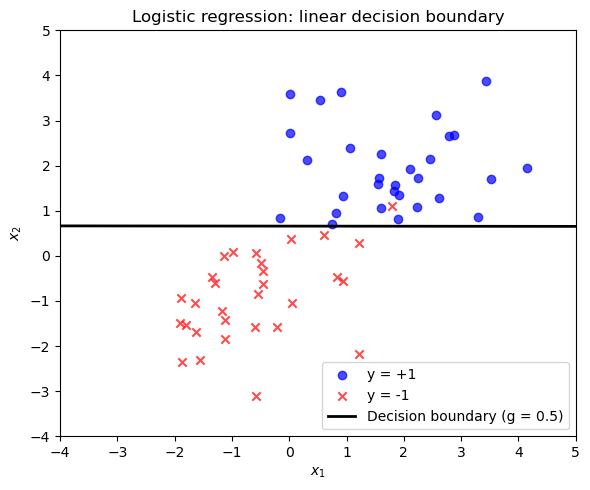


Verification: at boundary point x=[0.         0.65993383]
  g(x) = P(y=1|x) = 0.5000  (should be ≈ 0.5)


In [3]:
# Toy example 2: logistic regression decision boundary
from sklearn.linear_model import LogisticRegression

# 2D binary classification data
np.random.seed(SEED)
n_per_class = 30
X_pos = np.random.randn(n_per_class, 2) + np.array([2, 2])
X_neg = np.random.randn(n_per_class, 2) + np.array([-1, -1])
X_all = np.vstack([X_pos, X_neg])
y_all = np.array([1]*n_per_class + [-1]*n_per_class)

# Train logistic regression
clf = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
clf.fit(X_all, y_all)

theta_0 = clf.intercept_[0]
theta_1, theta_2 = clf.coef_[0]
print(f"Learned parameters:")
print(f"  theta_0 (intercept) = {theta_0:.4f}")
print(f"  theta_1 = {theta_1:.4f}")
print(f"  theta_2 = {theta_2:.4f}")

accuracy = clf.score(X_all, y_all)
print(f"Training accuracy: {accuracy:.2%}")

# Plot data + decision boundary
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_pos[:, 0], X_pos[:, 1], c='blue', marker='o', label='y = +1', alpha=0.7)
ax.scatter(X_neg[:, 0], X_neg[:, 1], c='red', marker='x', label='y = -1', alpha=0.7)

# Decision boundary: theta_0 + theta_1*x1 + theta_2*x2 = 0
# => x2 = -(theta_0 + theta_1*x1) / theta_2
x1_range = np.linspace(-4, 5, 200)
x2_boundary = -(theta_0 + theta_1 * x1_range) / theta_2
ax.plot(x1_range, x2_boundary, 'k-', linewidth=2, label='Decision boundary (g = 0.5)')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Logistic regression: linear decision boundary')
ax.legend()
ax.set_xlim(-4, 5)
ax.set_ylim(-4, 5)
plt.tight_layout()
plt.show()

# Verify: at the boundary, g(x) = 0.5
x_test = np.array([[0, -(theta_0) / theta_2]])  # point on boundary (x1=0)
prob = clf.predict_proba(x_test)
print(f"\nVerification: at boundary point x={x_test[0]}")
print(f"  g(x) = P(y=1|x) = {prob[0][1]:.4f}  (should be ≈ 0.5)")

---

## Toy example 3: polynomial regression and overfitting

Show how increasing polynomial degree fits training data more closely but can overfit.

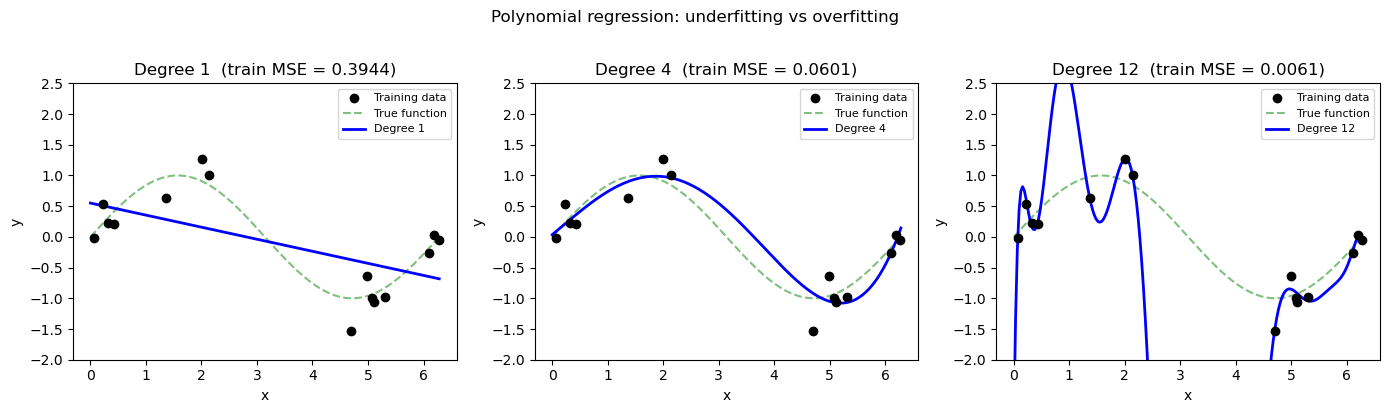

Degree 1:  underfitting — too rigid, misses the curve
Degree 4:  good balance — captures the shape without wild oscillations
Degree 12: overfitting — low training error but oscillates wildly between points


In [4]:
# Toy example 3: polynomial regression overfitting
np.random.seed(SEED)

# True function: y = sin(x) + noise
n_train = 15
x_train = np.sort(np.random.uniform(0, 2 * np.pi, n_train))
y_train = np.sin(x_train) + 0.3 * np.random.randn(n_train)

x_plot = np.linspace(0, 2 * np.pi, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
degrees = [1, 4, 12]

for ax, deg in zip(axes, degrees):
    # Build polynomial features
    X_train_poly = np.column_stack([x_train**d for d in range(deg + 1)])
    X_plot_poly = np.column_stack([x_plot**d for d in range(deg + 1)])

    # Fit via normal equations
    theta = np.linalg.lstsq(X_train_poly, y_train, rcond=None)[0]
    y_pred_train = X_train_poly @ theta
    y_pred_plot = X_plot_poly @ theta

    train_mse = np.mean((y_pred_train - y_train)**2)

    ax.scatter(x_train, y_train, c='black', zorder=5, label='Training data')
    ax.plot(x_plot, np.sin(x_plot), 'g--', alpha=0.5, label='True function')
    ax.plot(x_plot, y_pred_plot, 'b-', linewidth=2, label=f'Degree {deg}')
    ax.set_title(f'Degree {deg}  (train MSE = {train_mse:.4f})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_ylim(-2, 2.5)
    ax.legend(fontsize=8)

plt.suptitle('Polynomial regression: underfitting vs overfitting', y=1.02)
plt.tight_layout()
plt.show()

print("Degree 1:  underfitting — too rigid, misses the curve")
print("Degree 4:  good balance — captures the shape without wild oscillations")
print("Degree 12: overfitting — low training error but oscillates wildly between points")

---

## Week 4 wrap-up

**What to remember:**

1. **Parametric models** learn a fixed set of parameters $\boldsymbol{\theta}$ from data. Once trained, predictions depend only on $\boldsymbol{\theta}$, not the training data.
2. **Linear regression** minimises squared error; the normal equations give a closed-form solution $\hat{\boldsymbol{\theta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$.
3. **MLE under Gaussian noise** is equivalent to least squares — this is the statistical justification for squared error loss.
4. **Logistic regression** applies the logistic function to the linear model to produce class probabilities. Trained by minimising cross-entropy loss (no closed form).
5. **Decision boundary** of logistic regression: $g(\mathbf{x}) = 0.5 \Leftrightarrow \boldsymbol{\theta}^\top \mathbf{x} = 0$ — always a hyperplane.
6. **Polynomial regression** is still linear in $\boldsymbol{\theta}$; higher degree = more flexible = overfitting risk. Regularisation ($\lambda$) controls this trade-off.

**What connects forward:**
- Week 5 (Performance): how to evaluate and compare these models (generalisation, cross-validation, ROC curves).
- Week 6 (Learning Parametric Models): gradient descent for training logistic regression and other models without closed-form solutions; regularisation in depth.
- Week 7 (Neural Networks): the GLM framework generalises to neural networks by stacking non-linear transformations.
- Week 12 (Bayesian): Bayesian linear regression replaces the point estimate $\hat{\boldsymbol{\theta}}$ with a full posterior distribution over $\boldsymbol{\theta}$.

## Sources used

1. Lindholm, A., Wahlström, N., Lindsten, F., & Schön, T. B. (2022). *Machine Learning: A First Course for Engineers and Scientists*. Chapter 3. Cambridge University Press.
2. COMP4702/COMP7703 Course Summary Table, Semester 1, 2026.
3. COMP4702 Exam papers 2023–2025 (extracted from `references/`).